In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import pickle

In [2]:
epsilon = 0.001
nEstim = 100000
alpha = 0.05
nShotUnit = 1

In [69]:
pTrue = 0.2
results = np.array([])
errors = np.array([])
for i in range(nEstim):
    if i % 100 == 0:
        print(i)
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit, confint_method="chernoff")
    #result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit, confint_method="beta")
    results = np.append(results, result)
    errors = np.append(errors, result['Estimate'] - pTrue)

ax = plt.gca()
plt.plot(np.array(errors).cumsum())
plt.show()

0
100
200


KeyboardInterrupt: 

In [4]:
f = open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue02_epsilon0001_alpha005.dat","wb")
pickle.dump(results,f)
f.close

<function BufferedWriter.close>

In [8]:
np.mean(errors)

2.887864633437787e-06

In [6]:
np.sqrt(np.var(errors) / nEstim)

8.553701411805066e-07

In [7]:
result

{'Estimate': 0.20009607287476727,
 'TotalOracleCalls': 22828,
 'nGrover': [0, 2, 5, 11, 24, 53, 117, 258],
 'nShots': [382, 75, 225, 52, 36, 36, 39, 7],
 'n1s': [82, 34, 195, 46, 15, 12, 28, 5],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.3149922406795368, 0.6154843372404207],
  [0.43001520654622094, 0.5340140599715137],
  [0.42839899821678995, 0.4780364649980497],
  [0.4489141908341795, 0.4780684472854033],
  [0.45562616559799174, 0.4696025953918837],
  [0.46125852719330956, 0.4678289681340951],
  [0.46183666472304835, 0.4647367716482287],
  [0.46258005922906936, 0.4648584874267295]],
 'ampSqIntervals': [[0, 1],
  [0.09598167452959712, 0.33333769719815154],
  [0.1737927902368022, 0.2590734856739629],
  [0.17256963302735742, 0.21163371096657382],
  [0.1883452058612695, 0.21165983894256646],
  [0.19362172584711548, 0.20478515335328482],
  [0.19809216644724362, 0.20335553851434035],
  [0.19855321545462776, 0.20087204119372873],
  [0.19914664462873785, 0.20096958152935468]]}

In [3]:
from BiasCorrection import BiasTaylorExpTo2nd, BiasTaylorExpTo3rd, BiasTaylorExpTo4th

In [70]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230829_IQAE/results_IQAE_pTrue02_epsilon0001_alphaTot005.dat", 'rb') as f:
  results = pickle.load(f)

In [7]:
errors = np.array([r['Estimate'] - pTrue for r in results])

In [8]:
import pandas as pd

In [56]:
resultDf = pd.DataFrame(
    {
        "LastNGrover": [r['nGrover'][-1] for r in results],
        "LastNShot": [r['nShots'][-1] for r in results],
        "LastN1": [r['n1s'][-1] for r in results],
        "Estimate": [r['Estimate'] for r in results]
    }
)

In [114]:
resultDf["BiasTaylor3rd"] = BiasTaylorExpTo3rd(pTrue,resultDf["LastNGrover"],resultDf["LastNShot"])

In [115]:
resultDf["Error"] = resultDf["Estimate"] - pTrue

In [116]:
np.mean(resultDf["BiasTaylor3rd"])

0.028502283675362238

In [117]:
resultDf

,LastNGrover,LastNShot,LastN1,Estimate,BiasTaylor3rd,Error
0,234,12,6,0.200178,-7.845623e-06,0.000178
1,459,3,2,0.200182,-6.018097e-05,0.000182
2,361,5,4,0.199808,-1.401398e-05,-0.000192
3,307,7,1,0.200461,4.268455e-06,0.000461
4,331,7,1,0.200109,3.610376e-05,0.000109
...,...,...,...,...,...,...
99995,207,16,7,0.199896,-4.768291e-07,-0.000104
99996,248,7,6,0.200139,3.386138e-05,0.000139
99997,300,5,4,0.199790,-1.842732e-05,-0.000210
99998,246,8,1,0.200644,2.910385e-06,0.000644


In [118]:
resultDf[np.abs(resultDf["BiasTaylor3rd"]) > 1]

,LastNGrover,LastNShot,LastN1,Estimate,BiasTaylor3rd,Error
3011,506,3,3,0.199995,-65.986439,-0.000005
12288,362,6,0,0.200007,-37.340014,0.000007
13036,362,6,0,0.200007,-37.340014,0.000007
14470,589,2,0,0.199998,1070.026450,-0.000002
26720,362,6,0,0.200007,-37.340014,0.000007
31173,589,2,0,0.199998,1070.026450,-0.000002
33651,589,2,0,0.199998,1070.026450,-0.000002
35976,567,2,2,0.199984,-3.475439,-0.000016
39745,567,2,2,0.199984,-3.475439,-0.000016
47176,567,2,2,0.199984,-3.475439,-0.000016


In [119]:
notAll0OrAll1Final = (resultDf["LastNShot"] != resultDf["LastN1"]) & (resultDf["LastN1"] != 0)

In [120]:
resultDf_NotAll0OrAll1Final = resultDf[notAll0OrAll1Final]

In [121]:
len(resultDf_NotAll0OrAll1Final)

95403

In [122]:
errors_NotAll0OrAll1Final = resultDf_NotAll0OrAll1Final["Estimate"] - pTrue
np.mean(errors_NotAll0OrAll1Final)

2.5793702433597696e-06

In [123]:
np.std(errors_NotAll0OrAll1Final) / np.sqrt(nEstim)

8.063223131633634e-07

In [124]:
np.mean(resultDf_NotAll0OrAll1Final["BiasTaylor3rd"])

-1.936263316211098e-06

In [68]:
resultDf_NotAll0OrAll1Final

,LastNGrover,LastNShot,LastN1,Estimate,BiasTaylor3rd,Error
0,234,12,6,0.200178,5.679446e-08,0.000178
1,459,3,2,0.200182,-1.747258e-05,0.000182
2,361,5,4,0.199808,-3.144196e-05,-0.000192
3,307,7,1,0.200461,4.642501e-05,0.000461
4,331,7,1,0.200109,4.303192e-05,0.000109
...,...,...,...,...,...,...
99995,207,16,7,0.199896,-3.819798e-06,-0.000104
99996,248,7,6,0.200139,6.012116e-05,0.000139
99997,300,5,4,0.199790,-3.781139e-05,-0.000210
99998,246,8,1,0.200644,4.889854e-05,0.000644


IQAEBinom_OnlyFinalRoundの結果とBias理論式の比較　→　nShot=50とかなら合う

Final nShot=O(1)だと合わないみたい

In [71]:
from IQAEBinom_OnlyFinalRound import IQAEBinom_OnlyFinalRound

In [72]:
errorsOnlyFinalTest = np.array([])
for _ in range(100000):
    errorsOnlyFinalTest = np.append(errorsOnlyFinalTest, IQAEBinom_OnlyFinalRound(pTrue, 300, 5) - pTrue)

In [73]:
np.mean(errorsOnlyFinalTest)

-5.1369213749333055e-05

In [74]:
BiasTaylorExpTo3rd(pTrue, 300, 5)

-1.8427318698954412e-05

In [82]:
errorsOnlyFinalTest = np.array([])
for _ in range(100000):
    errorsOnlyFinalTest = np.append(errorsOnlyFinalTest, IQAEBinom_OnlyFinalRound(pTrue, 300, 50) - pTrue)

In [83]:
np.mean(errorsOnlyFinalTest)

-2.1845766549452113e-06

In [81]:
BiasTaylorExpTo3rd(pTrue, 300, 50)

-2.2169560623467115e-06

minRatioを上げてnShotを上げてみる →　余り様子変わらず...

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18

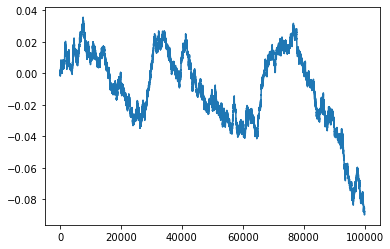

In [86]:
pTrue = 0.2
results_minRatio3 = np.array([])
errors_minRatio3 = np.array([])
for i in range(nEstim):
    if i % 100 == 0:
        print(i)
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit, confint_method="chernoff", minRatio=3)
    #result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit, confint_method="beta")
    results_minRatio3 = np.append(results_minRatio3, result)
    errors_minRatio3 = np.append(errors_minRatio3, result['Estimate'] - pTrue)

ax = plt.gca()
plt.plot(np.array(errors_minRatio3).cumsum())
plt.show()

In [88]:
resultDf_minratio3 = pd.DataFrame(
    {
        "LastNGrover": [r['nGrover'][-1] for r in results_minRatio3],
        "LastNShot": [r['nShots'][-1] for r in results_minRatio3],
        "LastN1": [r['n1s'][-1] for r in results_minRatio3],
        "Estimate": [r['Estimate'] for r in results_minRatio3]
    }
)
resultDf_minratio3["Error"] = resultDf_minratio3["Estimate"] - pTrue
resultDf_minratio3_NotAll0OrAll1Final = resultDf_minratio3[(resultDf_minratio3["LastNShot"] != resultDf_minratio3["LastN1"]) & (resultDf_minratio3["LastN1"] != 0)]

In [89]:
len(resultDf_minratio3_NotAll0OrAll1Final)

97413

In [90]:
np.mean(resultDf_minratio3_NotAll0OrAll1Final["Error"])

-1.1092355852832814e-06

In [98]:
np.std(resultDf_minratio3_NotAll0OrAll1Final["Error"]) / np.sqrt(len(resultDf_minratio3_NotAll0OrAll1Final))

8.570605672662327e-07

In [111]:
resultDf_minratio3_NotAll0OrAll1Final["BiasTaylor3rd"] = BiasTaylorExpTo3rd(pTrue,resultDf_minratio3_NotAll0OrAll1Final["LastNGrover"],resultDf_minratio3_NotAll0OrAll1Final["LastNShot"])

<ipython-input-111-a7d22461ee3e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resultDf_minratio3_NotAll0OrAll1Final["BiasTaylor3rd"] = BiasTaylorExpTo3rd(pTrue,resultDf_minratio3_NotAll0OrAll1Final["LastNGrover"],resultDf_minratio3_NotAll0OrAll1Final["LastNShot"])


In [112]:
resultDf_minratio3_NotAll0OrAll1Final

,LastNGrover,LastNShot,LastN1,Estimate,Error,BiasTaylor3rd
0,295,5,1,0.199684,-0.000316,-0.000013
1,251,7,1,0.199445,-0.000555,-0.000006
2,239,8,6,0.199864,-0.000136,-0.000017
3,302,10,9,0.200455,0.000455,0.000008
4,297,6,1,0.200228,0.000228,0.000027
...,...,...,...,...,...,...
99995,287,8,3,0.199693,-0.000307,0.000041
99996,224,9,7,0.200441,0.000441,0.000005
99997,280,6,1,0.200321,0.000321,0.000019
99998,263,8,1,0.200517,0.000517,0.000009


In [113]:
np.mean(resultDf_minratio3_NotAll0OrAll1Final["BiasTaylor3rd"])

-2.992706991142422e-07

nShotUnit増やす

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000


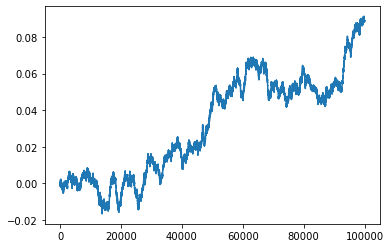

In [4]:
pTrue = 0.2
results_nShotUnit50 = np.array([])
errors_nShotUnit50 = np.array([])
for i in range(100000):
    if i % 1000 == 0:
        print(i)
    result = IQAEBinom(pTrue, epsilon, alpha, nShotUnit=50, confint_method="chernoff")
    results_nShotUnit50 = np.append(results_nShotUnit50, result)
    errors_nShotUnit50 = np.append(errors_nShotUnit50, result['Estimate'] - pTrue)

ax = plt.gca()
plt.plot(np.array(errors_nShotUnit50).cumsum())
plt.show()

In [6]:
f = open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue02_epsilon0001_alpha005_nShotUnit50.dat","wb")
pickle.dump(results_nShotUnit50,f)
f.close

<function BufferedWriter.close>

In [9]:
resultDf_nShotUnit50 = pd.DataFrame(
    {
        "LastNGrover": [r['nGrover'][-1] for r in results_nShotUnit50],
        "LastNShot": [r['nShots'][-1] for r in results_nShotUnit50],
        "LastN1": [r['n1s'][-1] for r in results_nShotUnit50],
        "Estimate": [r['Estimate'] for r in results_nShotUnit50]
    }
)
resultDf_nShotUnit50["Error"] = resultDf_nShotUnit50["Estimate"] - pTrue
resultDf_nShotUnit50_NotAll0OrAll1Final = resultDf_nShotUnit50[(resultDf_nShotUnit50["LastNShot"] != resultDf_nShotUnit50["LastN1"]) & (resultDf_nShotUnit50["LastN1"] != 0)]

In [10]:
len(resultDf_nShotUnit50_NotAll0OrAll1Final)

99769

In [11]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final["Error"])

9.581268982261423e-07

In [17]:
np.std(resultDf_nShotUnit50_NotAll0OrAll1Final["Error"])

0.00016376434152984157

In [12]:
np.std(resultDf_nShotUnit50_NotAll0OrAll1Final["Error"]) / np.sqrt(len(resultDf_nShotUnit50_NotAll0OrAll1Final))

5.184674949329549e-07

In [13]:
resultDf_nShotUnit50_NotAll0OrAll1Final["BiasTaylor4th"] = BiasTaylorExpTo4th(pTrue,resultDf_nShotUnit50_NotAll0OrAll1Final["LastNGrover"],resultDf_nShotUnit50_NotAll0OrAll1Final["LastNShot"])

<ipython-input-13-69fa41c91331>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resultDf_nShotUnit50_NotAll0OrAll1Final["BiasTaylor4th"] = BiasTaylorExpTo4th(pTrue,resultDf_nShotUnit50_NotAll0OrAll1Final["LastNGrover"],resultDf_nShotUnit50_NotAll0OrAll1Final["LastNShot"])


In [15]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final["BiasTaylor4th"])

1.1707666330529728e-07

In [16]:
resultDf_nShotUnit50_NotAll0OrAll1Final

,LastNGrover,LastNShot,LastN1,Estimate,Error,BiasTaylor4th
0,289,50,44,0.199724,-0.000276,3.410441e-05
1,160,50,45,0.200182,0.000182,1.322478e-05
2,312,50,19,0.199886,-0.000114,-4.173388e-07
3,126,100,77,0.200021,0.000021,5.058492e-06
4,263,50,21,0.199995,-0.000005,1.330897e-06
...,...,...,...,...,...,...
99995,126,50,32,0.199568,-0.000432,1.033889e-05
99996,170,50,35,0.199922,-0.000078,6.344531e-06
99997,197,50,31,0.199956,-0.000044,3.099892e-06
99998,244,50,15,0.200083,0.000083,-4.787851e-06


In [18]:
resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50 = \
    resultDf_nShotUnit50_NotAll0OrAll1Final[resultDf_nShotUnit50_NotAll0OrAll1Final["LastNShot"]==50]

In [19]:
len(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50)

97856

(array([   0.,  227.,  380.,  550.,  773.,  941., 1005., 1065., 1248.,
         947.,  973.,  988., 1620., 1864., 2294., 2350., 2539., 3114.,
        3554., 3611., 3619., 3664., 3750., 3719., 3634., 3610., 3585.,
        3574., 3539., 3325., 3242., 3046., 2888., 2790., 2595., 2433.,
        2167., 1794., 1665.,  915.,  958.,  996., 1014., 1046., 1016.,
         947.,  840.,  623.,  496.,  323.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.]),
 <BarContainer object of 50 artists>)

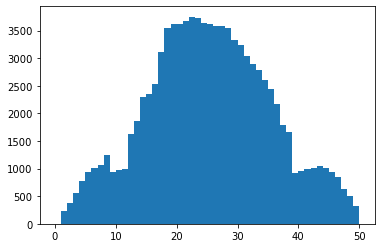

In [20]:
plt.hist(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50["LastN1"], range=(0,50), bins=50)

In [25]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50["Error"])

5.798911808169503e-07

In [26]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50["BiasTaylor4th"])

9.337377273049542e-08

In [22]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50.query("LastN1>=20 and LastN1<=30")["Error"])

-2.924467490643097e-06

In [21]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50.query("LastN1>=20 and LastN1<=30")["BiasTaylor4th"])

8.459386723583953e-08

In [23]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50.query("LastN1>=10 and LastN1<=40")["Error"])

1.0576437065844707e-06

In [24]:
np.mean(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50.query("LastN1>=10 and LastN1<=40")["BiasTaylor4th"])

5.1724260186761835e-08

ランダムに抽出した試行のnGrover, nShot(=50)を用いて、only-final-roundシミュレーションを行い、バイアスが理論式と一致するか見る

In [36]:
nGroverSamples = np.random.choice(np.unique(resultDf_nShotUnit50_NotAll0OrAll1Final_FinalNShot50["LastNGrover"]), size=100, replace=False)

In [39]:
from IQAEBinom_OnlyFinalRound import IQAEBinom_OnlyFinalRound

In [47]:
avgErrors = np.array([])
errStDevs = np.array([])
biasTaylor = np.array([])
for i in range(len(nGroverSamples)):
    print(i)
    nG = nGroverSamples[i]
    errs = np.array([])
    for _ in range(nEstim):
        errs = np.append(errs, IQAEBinom_OnlyFinalRound(pTrue, nG, 50) - pTrue)
    avgErrors = np.append(avgErrors, np.mean(errs))
    errStDevs = np.append(errStDevs, np.std(errs) / np.sqrt(nEstim))
    biasTaylor = np.append(biasTaylor, BiasTaylorExpTo4th(pTrue, nG, 50))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [54]:
dfErrorBias = pd.DataFrame({"nGrover": nGroverSamples, "avgError": avgErrors, "errorStd": errStDevs, "bias": biasTaylor})
dfErrorBias["(avgErr-bias)/errorStd"] = (dfErrorBias["avgError"] - dfErrorBias["bias"]) / dfErrorBias["errorStd"]
dfErrorBias["p1Final"] = np.sin((2 * dfErrorBias["nGrover"] + 1) * np.arcsin(np.sqrt(pTrue))) ** 2
dfErrorBias = dfErrorBias.sort_values("nGrover")

In [55]:
pd.options.display.float_format = '{:.4e}'.format
pd.set_option('display.max_rows', 100)
dfErrorBias

,nGrover,avgError,errorStd,bias,(avgErr-bias)/errorStd,p1Final
51,102,1.1504e-06,8.8140e-07,6.5972e-07,5.5673e-01,5.1458e-01
30,109,9.8591e-06,8.3058e-07,9.1143e-06,8.9666e-01,7.1520e-01
43,117,-8.1858e-06,7.7162e-07,-7.9716e-06,-2.7759e-01,7.0676e-01
22,119,2.5034e-06,7.5514e-07,2.5095e-06,-8.0643e-03,5.7040e-01
58,124,9.2583e-07,7.2725e-07,-1.2542e-07,1.4455e+00,5.0528e-01
11,128,5.1681e-05,8.4287e-07,3.9852e-05,1.4034e+01,4.8947e-02
50,131,7.4427e-06,6.9028e-07,6.8138e-06,9.1109e-01,3.0289e-01
13,138,1.8131e-05,6.7033e-07,1.6700e-05,2.1340e+00,1.3409e-01
4,139,-8.4743e-06,6.5211e-07,-7.4607e-06,-1.5543e+00,2.7533e-01
26,141,1.3948e-06,6.4043e-07,1.5239e-06,-2.0159e-01,4.4931e-01


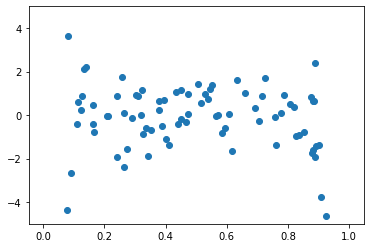

In [57]:
ax = plt.gca()
ax.set_ylim(-5,5)
plt.scatter(dfErrorBias["p1Final"], dfErrorBias["(avgErr-bias)/errorStd"])